In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

DATASET_DIR = Path('../learn_dataset_narrow_angle_fixed')
OUT_DIR = Path('.')

# スライド共通スタイル
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

In [32]:
# ピークが重なるサンプルをメタデータから探す
# 車両は物理的な大きさにより真値より約 5 ビン近距離側にピークが出るため
# 「ピーク一致」の条件は vehicle_true_r_idx - 5 ≈ cyclist_true_r_idx
VE_PEAK_OFFSET = 5

df = pd.read_csv(DATASET_DIR / 'metadata.csv')
df['ve_peak_r']   = df['vehicle_true_r_idx'] - VE_PEAK_OFFSET
df['peak_r_diff'] = abs(df['ve_peak_r'] - df['cyclist_true_r_idx'])
df['d_diff']      = abs(df['cyclist_true_d_idx'] - df['vehicle_true_d_idx'])

overlap = df[df['peak_r_diff'] <= 2].sort_values('peak_r_diff')
print(f'ピーク一致（|ve_peak - cy_r| <= 2）のサンプル数: {len(overlap)}')
cols = ['sample_id',
        'cyclist_true_d_idx', 'cyclist_true_r_idx',
        'vehicle_true_r_idx', 've_peak_r', 'peak_r_diff',
        'cyclist_true_angle_deg', 'vehicle_true_angle_deg']
print(overlap[cols].head(10).to_string(index=False))

ピーク一致（|ve_peak - cy_r| <= 2）のサンプル数: 24
 sample_id  cyclist_true_d_idx  cyclist_true_r_idx  vehicle_true_r_idx  ve_peak_r  peak_r_diff  cyclist_true_angle_deg  vehicle_true_angle_deg
        73                   1                 117                 122        117            0                3.298902                1.698297
        65                   1                 158                 163        158            0                2.925688                1.417509
       138                   1                 137                 142        137            0                3.109420                1.557606
       107                   1                 107                 112        107            0                3.393922                1.778348
       169                   1                 108                 113        108            0                3.383796                1.768690
       207                   1                 105                 110        105            0         

In [33]:
def load_sample(sample_id):
    """sample_id を渡すと npz を返す。"""
    path = DATASET_DIR / f'sample_{sample_id:05d}.npz'
    return np.load(path, allow_pickle=True)


def db(x, eps=1e-30):
    return 10 * np.log10(np.abs(x) ** 2 + eps)


def plot_rd_channel(ax, rd_maps, ch, fixed_angles,
                    cy_d, cy_r, ve_d, ve_r,
                    vmin, vmax,
                    r_lo=60, r_hi=190, d_lo=0, d_hi=8,
                    title=None):
    """1チャネルの RD マップを描画し、GT 位置にマーカーを打つ。"""
    power_db = db(rd_maps[ch])
    im = ax.imshow(
        power_db[d_lo:d_hi+1, r_lo:r_hi+1],
        aspect='auto', origin='lower', cmap='jet',
        vmin=vmin, vmax=vmax,
        extent=[r_lo, r_hi, d_lo, d_hi],
    )
    ax.plot(cy_r, cy_d, 'w+',  markersize=16, markeredgewidth=2.5, label='Cyclist GT')
    ax.plot(ve_r, ve_d, 'w^',  markersize=12, markeredgewidth=2.5, label='Vehicle GT')
    ax.set_xlabel('Range bin')
    ax.set_ylabel('Doppler bin')
    if title:
        ax.set_title(title)
    return im

Cyclist: d=1, r=149, angle=3.01°
Vehicle: d=1, r=155, peak≈150, angle=1.47°
fixed_angles: [1.   1.33 1.67 2.   2.33 2.67 3.   3.33 3.67 4.  ]
表示チャネル: [4] 2.33°


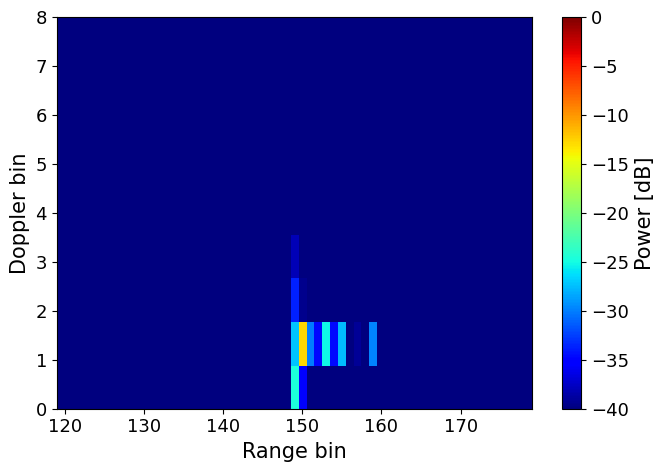

saved → rd_single_channel_00015.png


In [45]:
# ── Fig 1: 代表チャネル 1 枚で「ピーク重複」を示す ─────────────────────

SAMPLE_ID = 15
VMAX, VMIN = 0.0, -40.0

d = load_sample(SAMPLE_ID)
rd_maps      = d['rd_maps']       # (10, 89, 190) complex64
fixed_angles = d['fixed_angles']  # (10,) float32
cy_d   = int(d['cyclist_true_d_idx'])
cy_r   = int(d['cyclist_true_r_idx'])
ve_d   = int(d['vehicle_true_d_idx'])
ve_r   = int(d['vehicle_true_r_idx'])
ve_r_peak = ve_r - VE_PEAK_OFFSET
cy_ang = float(d['cyclist_true_angle_deg'])
ve_ang = float(d['vehicle_true_angle_deg'])

print(f'Cyclist: d={cy_d}, r={cy_r}, angle={cy_ang:.2f}°')
print(f'Vehicle: d={ve_d}, r={ve_r}, peak≈{ve_r_peak}, angle={ve_ang:.2f}°')
print(f'fixed_angles: {np.round(fixed_angles, 2)}')

R_C = (cy_r + ve_r_peak) // 2
R_LO, R_HI = max(0, R_C - 30), min(189, R_C + 30)
D_LO, D_HI = 0, 8

ch_mid = int(np.argmin(np.abs(fixed_angles - (cy_ang + ve_ang) / 2)))
print(f'表示チャネル: [{ch_mid}] {fixed_angles[ch_mid]:.2f}°')

fig, ax = plt.subplots(figsize=(7, 5))
power_db = db(rd_maps[ch_mid])
im = ax.imshow(
    power_db[D_LO:D_HI+1, R_LO:R_HI+1],
    aspect='auto', origin='lower', cmap='jet',
    vmin=VMIN, vmax=VMAX,
    extent=[R_LO, R_HI, D_LO, D_HI],
)
ax.set_xlabel('Range bin')
ax.set_ylabel('Doppler bin')
fig.colorbar(im, ax=ax, label='Power [dB]')
plt.tight_layout()
out = OUT_DIR / f'rd_single_channel_{SAMPLE_ID:05d}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'saved → {out}')

single fixed_angles: [1.   1.33 1.67 2.   2.33 2.67 3.   3.33 3.67 4.  ]
中間角度 2.24° → チャネル [4] 2.33°
cyclist peak_r=149,  vehicle peak_r=150,  diff=1


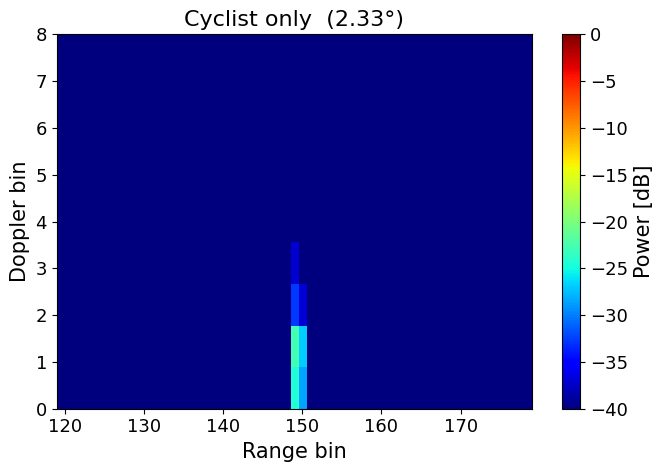

saved → rd_cyclist_only_00015.png


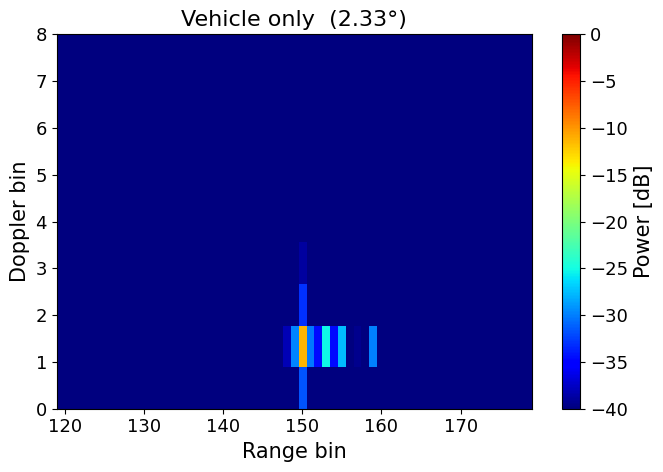

saved → rd_vehicle_only_00015.png


In [ ]:
# ── Fig 1b: 同シナリオの cyclist only / vehicle only RD マップ ───────────
# 単体 RD マップのピークが自然に一致するサンプルを使用
# peak_diff=0 の候補: sample 65 (cy=158, ve=158), 61 (cy=135, ve=135), 73 (cy=117, ve=117)

SINGLE_DIR = Path('../learn_dataset_narrow_angle_single')
df_single  = pd.read_csv(SINGLE_DIR / 'metadata.csv')

row_fixed = pd.read_csv(DATASET_DIR / 'metadata.csv')
row_fixed = row_fixed[row_fixed['sample_id'] == SAMPLE_ID].iloc[0]
src_cy = int(row_fixed['source_index_cyclist'])
src_ve = int(row_fixed['source_index_vehicle'])

cy_file = df_single[(df_single['source_index'] == src_cy) & (df_single['scenario'] == 'cyclist_only')].iloc[0]['file']
ve_file = df_single[(df_single['source_index'] == src_ve) & (df_single['scenario'] == 'vehicle_only')].iloc[0]['file']

d_cy_only = np.load(Path('..') / cy_file.lstrip('./'), allow_pickle=True)
d_ve_only = np.load(Path('..') / ve_file.lstrip('./'), allow_pickle=True)

fa_single     = d_cy_only['fixed_angles']
mid_ang       = (cy_ang + ve_ang) / 2
ch_single_mid = int(np.argmin(np.abs(fa_single - mid_ang)))

cy_peak_r = int(np.argmax(np.abs(d_cy_only['rd_maps'][ch_single_mid]).max(axis=0)))
ve_peak_r = int(np.argmax(np.abs(d_ve_only['rd_maps'][ch_single_mid]).max(axis=0)))
print(f'single fixed_angles: {np.round(fa_single, 2)}')
print(f'中間角度 {mid_ang:.2f}° → チャネル [{ch_single_mid}] {fa_single[ch_single_mid]:.2f}°')
print(f'cyclist peak_r={cy_peak_r},  vehicle peak_r={ve_peak_r},  diff={abs(cy_peak_r - ve_peak_r)}')

for d_s, tag, title in [
    (d_cy_only, 'cyclist_only', 'Cyclist only'),
    (d_ve_only, 'vehicle_only', 'Vehicle only'),
]:
    fig, ax = plt.subplots(figsize=(7, 5))
    power_db = db(d_s['rd_maps'][ch_single_mid])
    im = ax.imshow(
        power_db[D_LO:D_HI+1, R_LO:R_HI+1],
        aspect='auto', origin='lower', cmap='jet',
        vmin=VMIN, vmax=VMAX,
        extent=[R_LO, R_HI, D_LO, D_HI],
    )
    ax.set_xlabel('Range bin')
    ax.set_ylabel('Doppler bin')
    fig.colorbar(im, ax=ax, label='Power [dB]')
    plt.tight_layout()
    out = OUT_DIR / f'rd_{tag}_{SAMPLE_ID:05d}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'saved → {out}')

cy  チャネル: [7] 3.33°
ve  チャネル: [2] 1.67°


C:\Users\kousu\AppData\Local\Temp\ipykernel_23700\1248889451.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


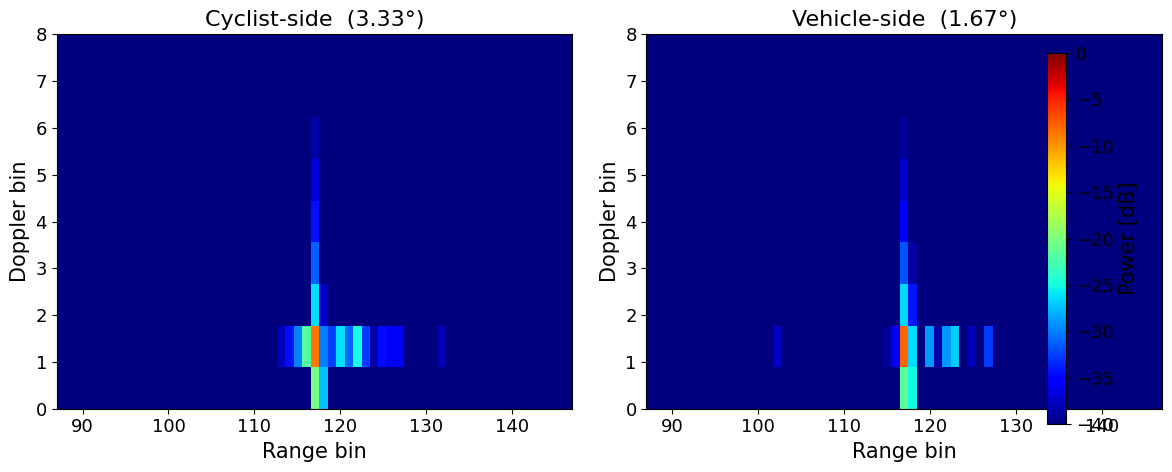

saved → rd_angle_comparison_00073.png


In [36]:
# ── Fig 2: cy 側 vs ve 側チャネルで「角度による分離」を示す ────────────

ch_cy = int(np.argmin(np.abs(fixed_angles - cy_ang)))
ch_ve = int(np.argmin(np.abs(fixed_angles - ve_ang)))
print(f'cy  チャネル: [{ch_cy}] {fixed_angles[ch_cy]:.2f}°')
print(f've  チャネル: [{ch_ve}] {fixed_angles[ch_ve]:.2f}°')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ch, label in [
    (axes[0], ch_cy, f'Cyclist-side  ({fixed_angles[ch_cy]:.2f}°)'),
    (axes[1], ch_ve, f'Vehicle-side  ({fixed_angles[ch_ve]:.2f}°)'),
]:
    power_db = db(rd_maps[ch])
    im = ax.imshow(
        power_db[D_LO:D_HI+1, R_LO:R_HI+1],
        aspect='auto', origin='lower', cmap='jet',
        vmin=VMIN, vmax=VMAX,
        extent=[R_LO, R_HI, D_LO, D_HI],
    )
    ax.set_xlabel('Range bin')
    ax.set_ylabel('Doppler bin')
    ax.set_title(label)

fig.colorbar(im, ax=axes, label='Power [dB]', fraction=0.02, pad=0.02)
plt.tight_layout()
out = OUT_DIR / f'rd_angle_comparison_{SAMPLE_ID:05d}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'saved → {out}')

Hard sample: 73  (peak_r_diff=0)
Easy sample: 281  (peak_r_diff=82)


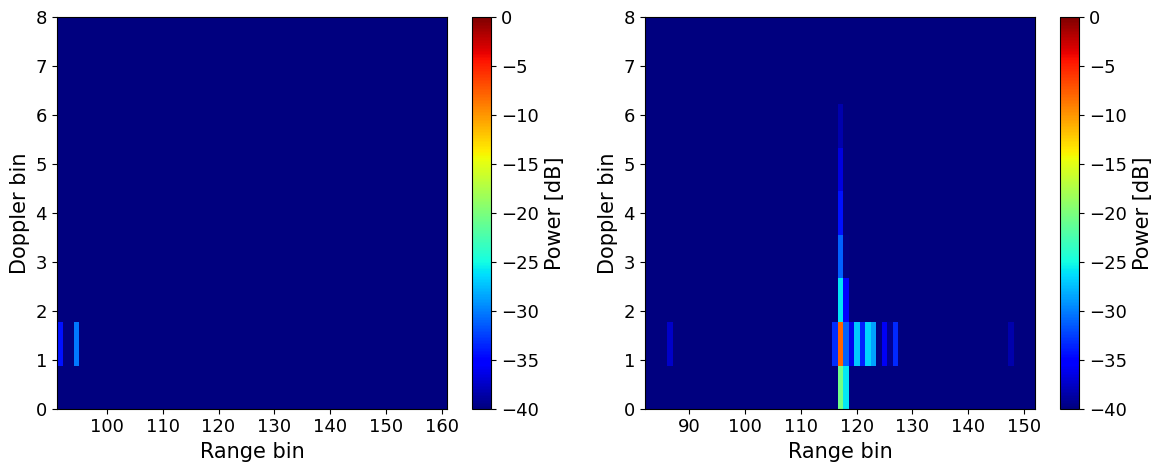

saved → rd_difficulty_comparison.png


In [37]:
# ── Fig 3: 難易度別比較（ピーク一致 vs ピーク十分離れ）────────────────

hard_id  = 73
easy_row = df.nlargest(1, 'peak_r_diff').iloc[0]
easy_id  = int(easy_row['sample_id'])
print(f'Hard sample: {hard_id}  (peak_r_diff=0)')
print(f'Easy sample: {easy_id}  (peak_r_diff={int(easy_row["peak_r_diff"])})')


def get_mid_channel(d):
    cy_ang_ = float(d['cyclist_true_angle_deg'])
    ve_ang_ = float(d['vehicle_true_angle_deg'])
    return int(np.argmin(np.abs(d['fixed_angles'] - (cy_ang_ + ve_ang_) / 2)))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, sid, label in [
    (axes[0], easy_id, 'Well-separated'),
    (axes[1], hard_id, 'Overlapping peaks'),
]:
    d_s         = load_sample(sid)
    ch          = get_mid_channel(d_s)
    rd          = d_s['rd_maps']
    cy_r_s      = int(d_s['cyclist_true_r_idx'])
    ve_r_peak_s = int(d_s['vehicle_true_r_idx']) - VE_PEAK_OFFSET
    fa_s        = d_s['fixed_angles']

    R_C_s  = (cy_r_s + ve_r_peak_s) // 2
    R_LO_s, R_HI_s = max(0, R_C_s - 35), min(189, R_C_s + 35)
    peak_diff = abs(cy_r_s - ve_r_peak_s)

    power_db = db(rd[ch])
    im = ax.imshow(
        power_db[0:9, R_LO_s:R_HI_s+1],
        aspect='auto', origin='lower', cmap='jet',
        vmin=-40.0, vmax=0.0,
        extent=[R_LO_s, R_HI_s, 0, 8],
    )
    ax.set_xlabel('Range bin')
    ax.set_ylabel('Doppler bin')
    plt.colorbar(im, ax=ax, label='Power [dB]')

plt.tight_layout()
out = OUT_DIR / 'rd_difficulty_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'saved → {out}')